<a href="https://colab.research.google.com/github/dorcasojo/AVCAD-/blob/main/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/EFIplus_medit.csv", sep=";")

In [31]:
top4 = (df.groupby("Catchment_name")
          .size()
          .nlargest(4)
          .index
          .tolist())

data4 = df[df["Catchment_name"].isin(top4)][["Catchment_name", "temp_ann"]].dropna()

In [32]:
palette = dict(zip(top4, sns.color_palette("Set2", 4)))

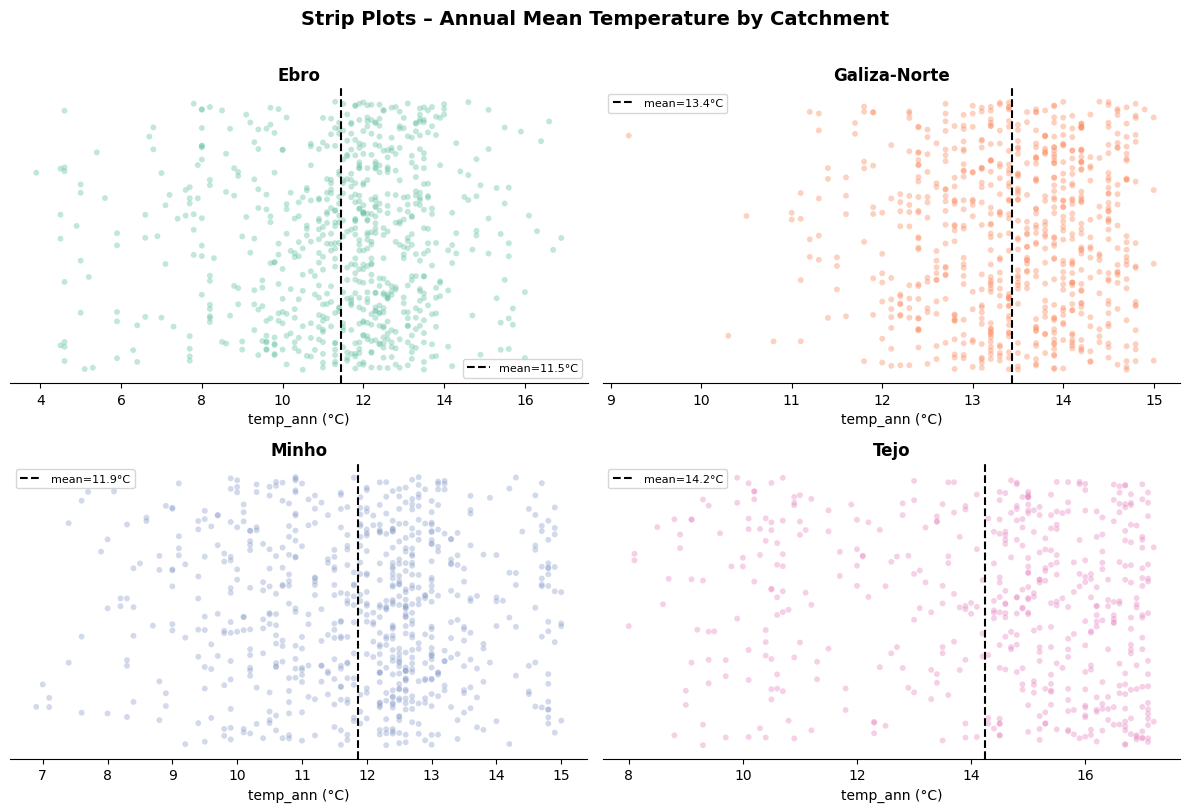

In [8]:
##STRIP PLOTS
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
fig.suptitle("Strip Plots – Annual Mean Temperature by Catchment",
             fontsize=14, fontweight="bold", y=1.01)

for ax, cat in zip(axes.flat, top4):
    sub = data4[data4["Catchment_name"] == cat]["temp_ann"]
    ax.scatter(sub, np.random.uniform(-0.3, 0.3, len(sub)),
               alpha=0.4, s=18, color=palette[cat], edgecolors="none")
    ax.axvline(sub.mean(), color="black", lw=1.5, linestyle="--", label=f"mean={sub.mean():.1f}°C")
    ax.set_title(cat, fontweight="bold")
    ax.set_xlabel("temp_ann (°C)")
    ax.set_yticks([])
    ax.legend(fontsize=8)
    ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.savefig("strip_plots.png", dpi=150, bbox_inches="tight")
plt.show()

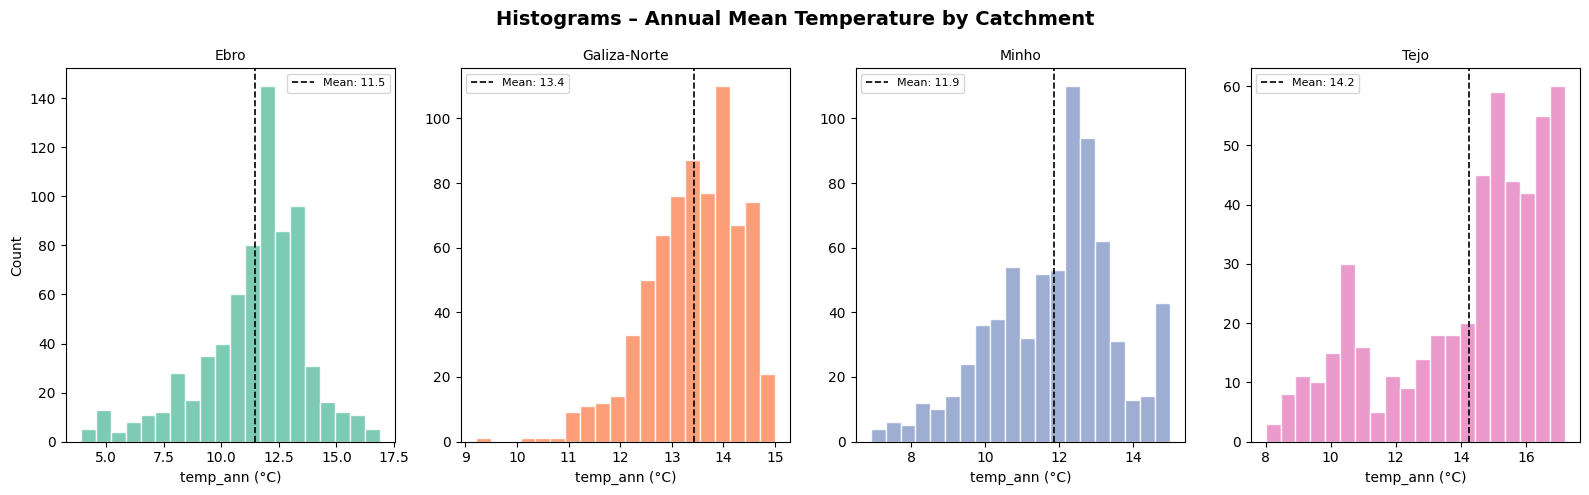

In [10]:
##HISTOGRMA

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
fig.suptitle('Histograms – Annual Mean Temperature by Catchment', fontsize=14, fontweight='bold')

for ax, cat in zip(axes, top4):
    sub = data4[data4['Catchment_name'] == cat]['temp_ann']
    ax.hist(sub, bins=20, color=palette[cat], edgecolor='white', alpha=0.85)
    ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean: {sub.mean():.1f}')
    ax.set_title(cat, fontsize=10)
    ax.set_xlabel('temp_ann (°C)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Count')
plt.tight_layout()
plt.savefig('histograms.png', dpi=150)
plt.show()

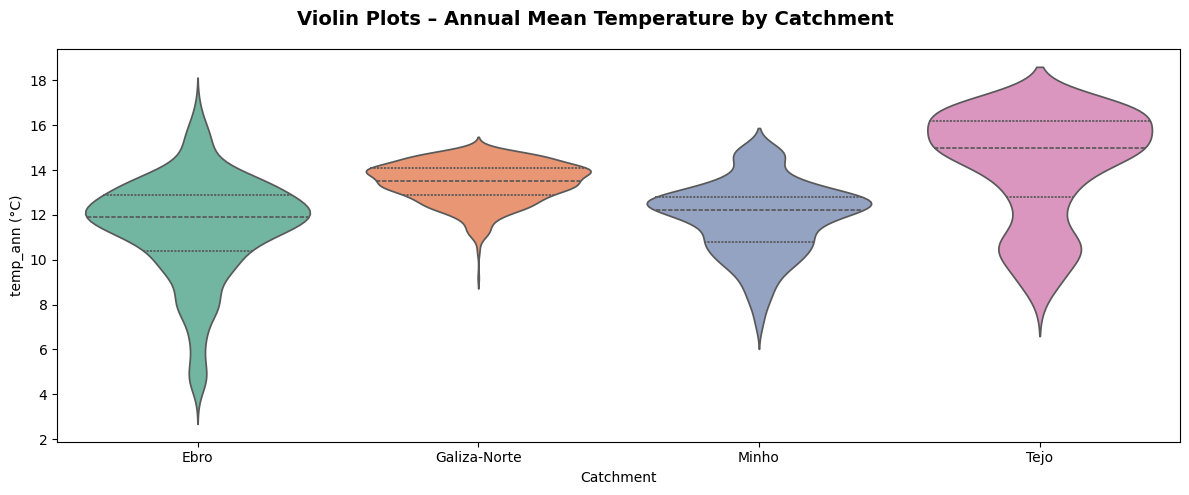

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Violin Plots – Annual Mean Temperature by Catchment', fontsize=14, fontweight='bold')

sns.violinplot(data=data4, x='Catchment_name', y='temp_ann', hue='Catchment_name', order=top4,
               palette=palette, inner='quartile', ax=ax, legend=False)
ax.set_xlabel('Catchment')
ax.set_ylabel('temp_ann (°C)')
plt.tight_layout()
plt.savefig('violin_plots.png', dpi=150)
plt.show()

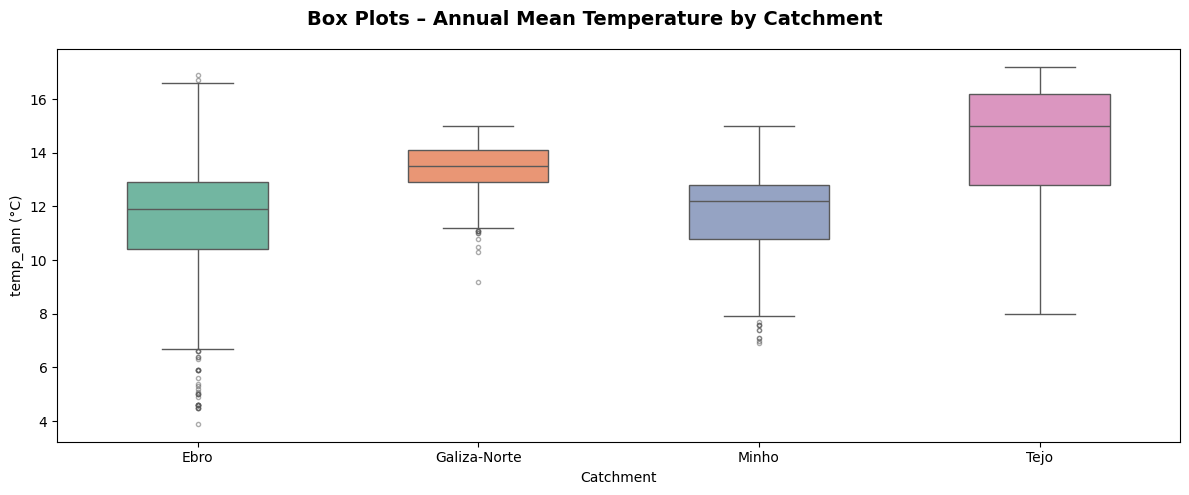

In [16]:
##BOXPLOT
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Box Plots – Annual Mean Temperature by Catchment', fontsize=14, fontweight='bold')

sns.boxplot(data=data4, x='Catchment_name', y='temp_ann', hue='Catchment_name', order=top4,
            palette=palette, width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.5), ax=ax, legend=False)
ax.set_xlabel('Catchment')
ax.set_ylabel('temp_ann (°C)')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

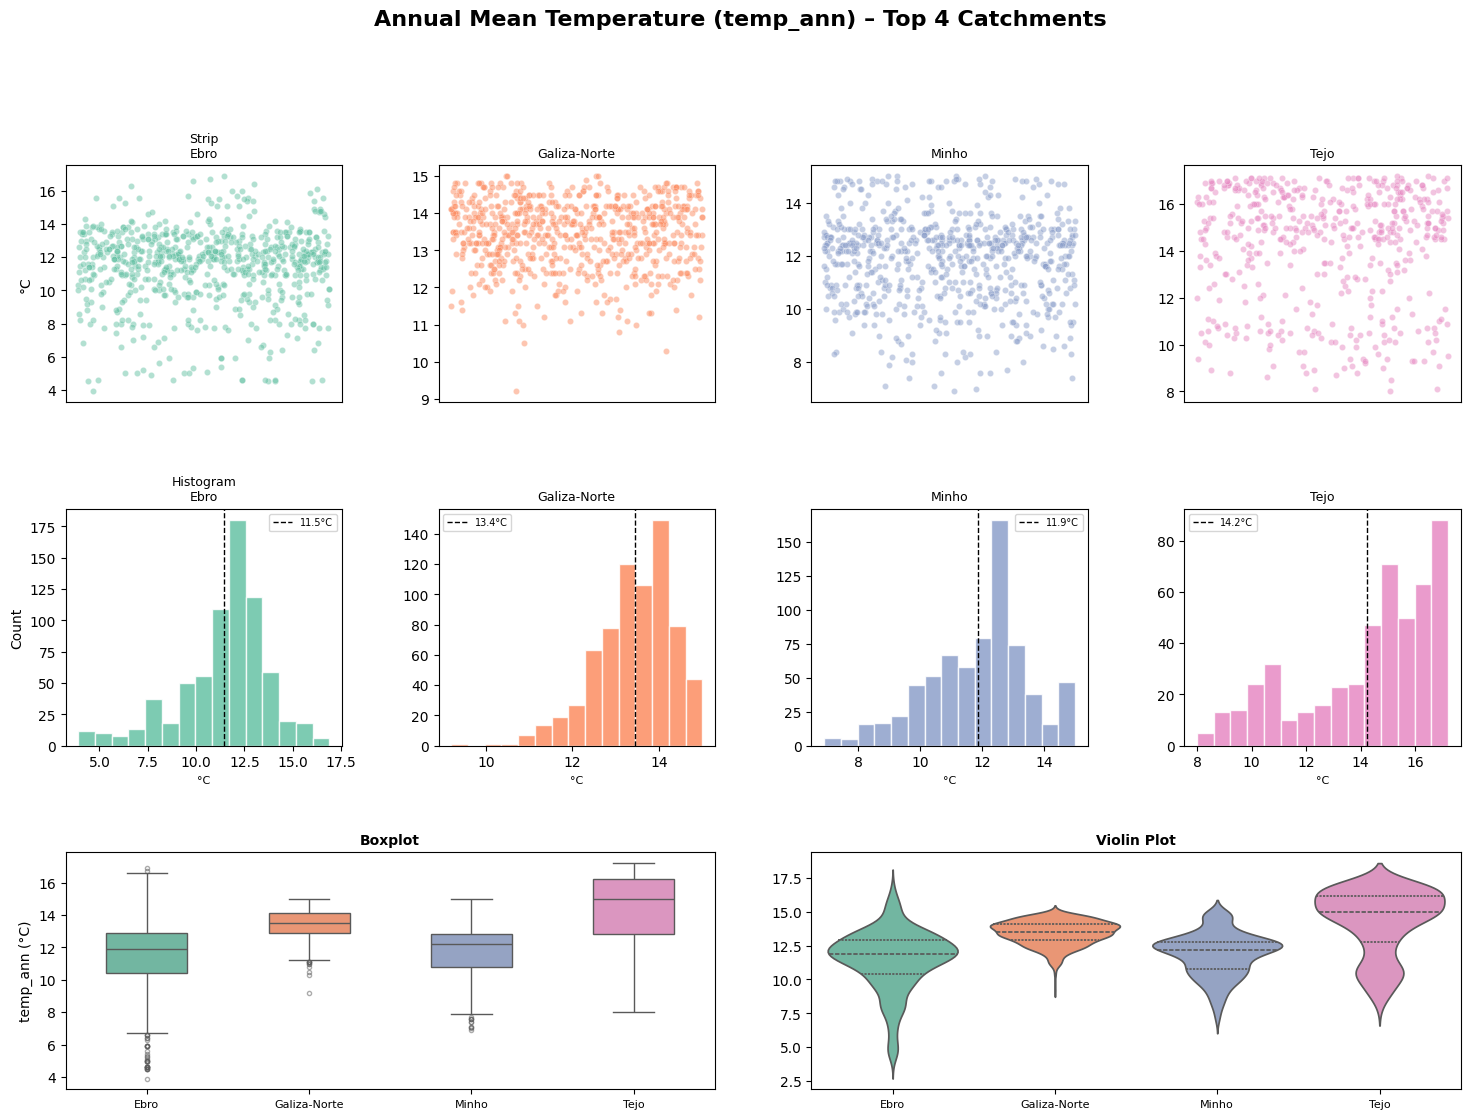

Done! All plots saved.


In [19]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Annual Mean Temperature (temp_ann) – Top 4 Catchments', fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# Row 0: strip plots
for i, cat in enumerate(top4):
    ax = fig.add_subplot(gs[0, i])
    sub = data4[data4['Catchment_name'] == cat]['temp_ann']
    ax.scatter(np.random.uniform(-0.2, 0.2, len(sub)),
               sub, alpha=0.5, color=palette[cat], edgecolors='white', linewidths=0.3, s=20)
    ax.set_title(cat, fontsize=9)
    ax.set_xticks([])

    ax.set_ylabel('°C' if i == 0 else '')
    if i == 0: ax.set_title(f'Strip\n{cat}', fontsize=9)

# Row 1: histograms
for i, cat in enumerate(top4):
    ax = fig.add_subplot(gs[1, i])
    sub = data4[data4['Catchment_name'] == cat]['temp_ann']
    ax.hist(sub, bins=15, color=palette[cat], edgecolor='white', alpha=0.85)
    ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1, label=f'{sub.mean():.1f}°C')
    ax.set_xlabel('°C', fontsize=8)
    ax.set_ylabel('Count' if i == 0 else '')
    ax.legend(fontsize=7)
    if i == 0: ax.set_title(f'Histogram\n{cat}', fontsize=9)
    else: ax.set_title(cat, fontsize=9)

# Row 2: box + violin side by side (span all 4 cols each)
ax_box = fig.add_subplot(gs[2, :2])
sns.boxplot(data=data4, x='Catchment_name', y='temp_ann', hue='Catchment_name', order=top4,
            palette=palette, width=0.5, ax=ax_box,
            flierprops=dict(marker='o', markersize=3, alpha=0.5), legend=False)
ax_box.set_title('Boxplot', fontsize=10, fontweight='bold')
ax_box.set_xlabel('')
ax_box.set_ylabel('temp_ann (°C)')
ax_box.tick_params(axis='x', labelsize=8)

ax_vio = fig.add_subplot(gs[2, 2:])
sns.violinplot(data=data4, x='Catchment_name', y='temp_ann', hue='Catchment_name', order=top4,
               palette=palette, inner='quartile', ax=ax_vio, legend=False)
ax_vio.set_title('Violin Plot', fontsize=10, fontweight='bold')
ax_vio.set_xlabel('')
ax_vio.set_ylabel('')
ax_vio.tick_params(axis='x', labelsize=8)

plt.savefig('combined_panel.png', dpi=150, bbox_inches='tight')
plt.show()

print("Done! All plots saved.")
# A few things to check before running:
#
# File name — after unzipping EFIplus_medit.zip, check the actual filename inside and update pd.read_csv('EFIplus_medit.csv') accordingly.
# Column names — confirm 'Catchment' and 'temp_ann' match exactly what's in your dataset (run df.columns.tolist() if unsure).
# The 5th plot is a combined summary panel that fits all four plot types in one window — that's the one most useful for your report.
# Want to be notified when Claude responds?

**QUETION 2**
**PROMPT: "I want to explore how the sample mean of temp_ann stabilizes as sample size grows. Can you write me code that takes 1000 random samples with replacement at increasing sample sizes (10, 50, 100, 150, 200, 250, 300, 500 and 1000),**

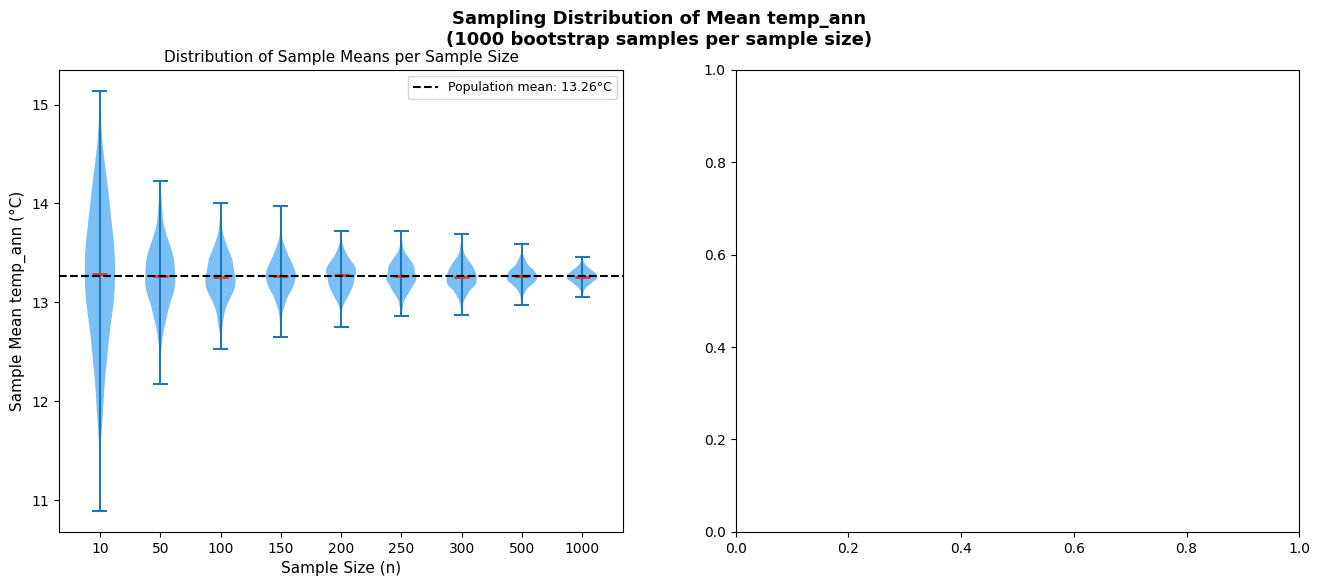

In [30]:
temp = df['temp_ann'].dropna().values

pop_mean = temp.mean()
sigma = np.std(temp)

sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]
n_samples = 1000

np.random.seed(42)
results = {}
for n in sample_sizes:
    results[n] = [np.random.choice(temp, size=n, replace=True).mean() for _ in range(n_samples)]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sampling Distribution of Mean temp_ann\n(1000 bootstrap samples per sample size)',
             fontsize=13, fontweight='bold')

# ── Left: Violin plot ──
ax = axes[0]
parts = ax.violinplot([results[n] for n in sample_sizes],
                      positions=range(len(sample_sizes)),
                      showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('#2196F3')
    pc.set_alpha(0.6)
parts['cmedians'].set_color('#E53935')
parts['cmedians'].set_linewidth(2)

ax.axhline(pop_mean, color='black', linestyle='--', linewidth=1.5,
           label=f'Population mean: {pop_mean:.2f}°C')
ax.set_xticks(range(len(sample_sizes)))
ax.set_xticklabels(sample_sizes)
ax.set_xlabel('Sample Size (n)', fontsize=11)
ax.set_ylabel('Sample Mean temp_ann (°C)', fontsize=11)
ax.set_title('Distribution of Sample Means per Sample Size', fontsize=11)
ax.legend(fontsize=9)

In [34]:
ax2 = axes[1]
stds = [np.std(results[n]) for n in sample_sizes]
theoretical = [sigma / np.sqrt(n) for n in sample_sizes]

ax2.plot(sample_sizes, stds, 'o-', color='#2196F3', linewidth=2,
         markersize=7, label='Observed SD of sample means')
ax2.plot(sample_sizes, theoretical, 's--', color='#E53935', linewidth=1.5,
         markersize=6, label='Theoretical SEM (σ/√n)')

threshold = 0.5
ax2.axhline(threshold, color='grey', linestyle=':', linewidth=1.2,
            label=f'Threshold: {threshold}°C')
converged = next((n for n, s in zip(sample_sizes, stds) if s < threshold), None)
if converged:
    idx = sample_sizes.index(converged)
    ax2.annotate(f'n={converged}\nSD < {threshold}°C',
                 xy=(converged, stds[idx]),
                 xytext=(converged + 40, stds[idx] + 0.1),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

ax2.set_xlabel('Sample Size (n)', fontsize=11)
ax2.set_ylabel('SD of Sample Means (°C)', fontsize=11)
ax2.set_title('Convergence of Sample Mean to Population Mean', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_xticks(sample_sizes)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('sampling_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>